# Cohort Data Creation

In [1]:
import pandas as pd
from LabData.DataLoaders.GutMBLoader import GutMBLoader
from LabData.DataLoaders.SubjectLoader import SubjectLoader
from LabData.DataLoaders.DietLoggingLoader import DietLoggingLoader
from LabData.DataLoaders.LifeStyleLoader import LifeStyleLoader
from LabData.DataLoaders.BodyMeasuresLoader import BodyMeasuresLoader
from LabData.DataAnalyses.TenK_Trajectories.utils import get_diet_logging_around_stage
import numpy as np
import pickle
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


In [2]:
home_path = '/net/mraid20/export/genie/LabData/Analyses/tomerse/diet_mb/'
SPECIES = 'segal_species' # 'segal_species' or 'mpa_species'

# Study configuration
study_ids = [15]  # [15] for Australian cohort, ['AUS'] for AUS
# Map study_ids to study name for file naming
study_name_map = {15: 'AUS', 'AUS': 'AUS'}
study_name = study_name_map.get(study_ids[0] if isinstance(study_ids[0], int) else study_ids[0], f'study_{study_ids[0]}')

min_col_present_frac = 0.05

In [3]:
diet_mb_10k = pd.read_pickle(home_path + f"data/{SPECIES}/diet_mb.pkl")
with open(home_path + f'data/{SPECIES}/my_lists.pkl', 'rb') as file:
    loaded_lists = pickle.load(file)
base_features_10k, all_features_10k, targets_10k = loaded_lists
with open(home_path + f'data/{SPECIES}/scaler.pkl', 'rb') as scaler_file:
        scaler_10k = pickle.load(scaler_file)
diet_mb_10k

,Acorn squash,Alfalfa sprouts,Almond Beverage,Almond flour,Almond spread,Almonds,Amba,Apple,Apple Cake,Apple Vinegar,...,Irritable Bowel Syndrome (IBS),Peptic Ulcer Disease,Gallstone disease,Asthma,Atopic dermatitis,Psoriasis,Allergy,Depression,Anxiety,Hypothyroidism
RegistrationCode,,,,,,,,,,,,,,,,,,,,,
10K_1000942861,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.016416,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
10K_1001201093,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.013895,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10K_1002254441,0.0,0.0,0.0,0.0,0.0,0.081238,0.0,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10K_1003113258,0.0,0.0,0.0,0.0,0.0,0.002048,0.0,0.008929,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10K_1007330152,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10K_9996884777,0.0,0.0,0.0,0.0,0.0,0.002401,0.0,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10K_9998420917,0.0,0.0,0.0,0.0,0.0,0.019995,0.0,0.018783,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10K_9998635752,0.0,0.0,0.0,0.0,0.0,0.001607,0.0,0.011305,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
def explore_columns(df):
    for column in df.columns:
        print(column)
        print(df[column].value_counts())

# study_ids is defined in cell 2
subjects_dl = SubjectLoader()
subjects_data = subjects_dl.get_data(groupby_reg='first', study_ids=study_ids)
subjects_df = subjects_data.df
print(subjects_df)

                             StudyTypeID  city country  gender month_of_birth  \
RegistrationCode Date                                                           
3002243          NaT                15.0  None      AU     NaN           None   
3002905          2023-01-01         15.0  None      AU     0.0           None   
3006146          NaT                15.0  None      AU     NaN           None   
3014896          2020-01-01         15.0  None      AU     1.0           None   
3015169          NaT                15.0  None      AU     NaN           None   
...                                  ...   ...     ...     ...            ...   
3974179          2020-01-01         15.0  None      AU     1.0           None   
3976912          2020-01-01         15.0  None      AU     0.0           None   
3987074          NaT                15.0  None      AU     NaN           None   
3991756          NaT                15.0  None      AU     NaN           None   
3993066          NaT        

## Load Microbiome Data

In [5]:
gut_bacteria = GutMBLoader().get_data(SPECIES, subjects_df=subjects_df, study_ids=study_ids,
                                groupby_reg='first', 
                                genotek_vals=[1], min_col_val=1e-4, take_log=True)
gut_bacteria_df = gut_bacteria.df.dropna(axis=1, how='all')
gut_bacteria_df.columns = gut_bacteria_df.columns.str.replace('s__', '')
# with open(home_path + f'data/{species}/my_lists.pkl', 'rb') as file:
#         loaded_lists = pickle.load(file)
# base_features, all_diet_features, targets = loaded_lists
gut_bacteria_df = gut_bacteria_df[targets_10k]



gut_bacteria_df.head(3)

/home/tomerse/.local/lib/python3.7/site-packages/pandas/core/frame.py:6402: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  key,


species,fBin__100|gBin__473|sBin__693,fBin__100|gBin__473|sBin__694,fBin__100|gBin__474|sBin__695,fBin__100|gBin__477|sBin__698,fBin__100|gBin__481|sBin__704,fBin__100|gBin__481|sBin__705,fBin__100|gBin__481|sBin__706,fBin__100|gBin__483|sBin__709,fBin__102|gBin__490|sBin__720,fBin__102|gBin__490|sBin__721,...,fBin__86|gBin__428|sBin__630,fBin__86|gBin__429|sBin__631,fBin__88|gBin__434|sBin__637,fBin__94|gBin__448|sBin__654,fBin__94|gBin__449|sBin__656,fBin__95|gBin__450|sBin__659,fBin__96|gBin__457|sBin__669,fBin__97|gBin__462|sBin__676,fBin__97|gBin__462|sBin__678,fBin__99|gBin__469|sBin__687
SampleName,,,,,,,,,,,,,,,,,,,,,
131303668395536_v2_fullrun,-4.0,-4.0,-4.00000,-4.000000,-4.0,-4.0,-4.0,-4.0,-4.0,-4.000000,...,-4.0,-4.0,-4.0,-2.645027,-4.0,-4.0,-4.0,-4.0,-3.055171,-4.0
131323320780891_v2_fullrun,-4.0,-4.0,-4.00000,-4.000000,-4.0,-4.0,-4.0,-4.0,-4.0,-3.042893,...,-4.0,-4.0,-4.0,-4.000000,-4.0,-4.0,-4.0,-4.0,-2.556423,-4.0
131353237430853_v2_fullrun,-4.0,-4.0,-2.13568,-2.508924,-4.0,-4.0,-4.0,-4.0,-4.0,-4.000000,...,-4.0,-4.0,-4.0,-3.616712,-4.0,-4.0,-4.0,-4.0,-2.522924,-4.0


In [6]:
gut_bacteria_df.shape

(150, 724)

In [7]:
gut_bacteria_df

species,fBin__100|gBin__473|sBin__693,fBin__100|gBin__473|sBin__694,fBin__100|gBin__474|sBin__695,fBin__100|gBin__477|sBin__698,fBin__100|gBin__481|sBin__704,fBin__100|gBin__481|sBin__705,fBin__100|gBin__481|sBin__706,fBin__100|gBin__483|sBin__709,fBin__102|gBin__490|sBin__720,fBin__102|gBin__490|sBin__721,...,fBin__86|gBin__428|sBin__630,fBin__86|gBin__429|sBin__631,fBin__88|gBin__434|sBin__637,fBin__94|gBin__448|sBin__654,fBin__94|gBin__449|sBin__656,fBin__95|gBin__450|sBin__659,fBin__96|gBin__457|sBin__669,fBin__97|gBin__462|sBin__676,fBin__97|gBin__462|sBin__678,fBin__99|gBin__469|sBin__687
SampleName,,,,,,,,,,,,,,,,,,,,,
131303668395536_v2_fullrun,-4.0,-4.00000,-4.00000,-4.000000,-4.0,-4.000000,-4.0,-4.000000,-4.000000,-4.000000,...,-4.0,-4.000000,-4.000000,-2.645027,-4.0,-4.0,-4.0,-4.000000,-3.055171,-4.000000
131323320780891_v2_fullrun,-4.0,-4.00000,-4.00000,-4.000000,-4.0,-4.000000,-4.0,-4.000000,-4.000000,-3.042893,...,-4.0,-4.000000,-4.000000,-4.000000,-4.0,-4.0,-4.0,-4.000000,-2.556423,-4.000000
131353237430853_v2_fullrun,-4.0,-4.00000,-2.13568,-2.508924,-4.0,-4.000000,-4.0,-4.000000,-4.000000,-4.000000,...,-4.0,-4.000000,-4.000000,-3.616712,-4.0,-4.0,-4.0,-4.000000,-2.522924,-4.000000
131393599090217_v2_fullrun,-4.0,-4.00000,-4.00000,-4.000000,-4.0,-4.000000,-4.0,-4.000000,-4.000000,-3.835409,...,-4.0,-4.000000,-4.000000,-4.000000,-4.0,-4.0,-4.0,-4.000000,-1.784588,-4.000000
131403088478160_v2_fullrun,-4.0,-4.00000,-4.00000,-2.529034,-4.0,-4.000000,-4.0,-2.149378,-4.000000,-4.000000,...,-4.0,-3.565438,-2.228209,-4.000000,-4.0,-4.0,-4.0,-4.000000,-4.000000,-3.065981
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3898313_v2_fullrun,-4.0,-4.00000,-3.20460,-3.089961,-4.0,-2.486368,-4.0,-2.397183,-4.000000,-4.000000,...,-4.0,-4.000000,-3.348478,-4.000000,-4.0,-4.0,-4.0,-4.000000,-4.000000,-4.000000
3911362_v2_fullrun,-4.0,-4.00000,-4.00000,-4.000000,-4.0,-4.000000,-4.0,-4.000000,-3.820609,-2.978476,...,-4.0,-4.000000,-4.000000,-4.000000,-4.0,-4.0,-4.0,-4.000000,-2.212831,-4.000000
39244661501_v2_fullrun,-4.0,-4.00000,-4.00000,-4.000000,-4.0,-4.000000,-4.0,-4.000000,-4.000000,-2.623527,...,-4.0,-4.000000,-4.000000,-4.000000,-4.0,-4.0,-4.0,-2.727943,-2.318047,-4.000000


In [8]:
gut_bacteria.df_metadata

,RegistrationCode,GenesetMapCount,HGMappedRC,MPAMapCount,Nextera,PE,PostBBDRC,PostHGFRC,PostQCRC,PostTrimRC,...,age,tz,StudyTypeID3,country,StudyTypeID4,yob,gender,StudyTypeID8,StudyTypeID5,StudyTypeID2
SampleName,,,,,,,,,,,,,,,,,,,,,
131303668395536_v2_fullrun,3668395,NaN,1241.0,NaN,None,False,8267486.0,9236289.0,9241475.0,NaN,...,70.0,Australia/Sydney,NaN,AU,NaN,1952.0,1.0,NaN,NaN,NaN
131323320780891_v2_fullrun,3320780,NaN,2066.0,NaN,None,False,NaN,11018163.0,11026254.0,NaN,...,70.0,Australia/Sydney,NaN,AU,NaN,1952.0,0.0,NaN,NaN,NaN
131353237430853_v2_fullrun,3237430,NaN,5539.0,NaN,None,False,10276435.0,9800605.0,9809742.0,NaN,...,57.0,Australia/Sydney,NaN,AU,NaN,1965.0,1.0,NaN,NaN,NaN
131393599090217_v2_fullrun,3599090,NaN,8679.0,NaN,None,False,NaN,9457472.0,9466270.0,NaN,...,68.0,Australia/Sydney,NaN,AU,NaN,1954.0,0.0,NaN,NaN,NaN
131403088478160_v2_fullrun,3088478,NaN,2397.0,NaN,None,False,7720971.0,4956349.0,4965147.0,NaN,...,67.0,Australia/Sydney,NaN,AU,NaN,1955.0,1.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3898313_v2_fullrun,3898313,NaN,3024.0,NaN,None,False,8430159.0,9613356.0,9616380.0,NaN,...,61.0,Australia/Sydney,NaN,AU,NaN,1959.0,0.0,NaN,NaN,NaN
3911362_v2_fullrun,3911362,NaN,2327.0,NaN,None,False,9247817.0,9555907.0,9560174.0,NaN,...,49.0,Australia/Sydney,NaN,AU,NaN,1972.0,0.0,NaN,NaN,NaN
39244661501_v2_fullrun,3924466,NaN,10427.0,NaN,None,False,8769763.0,9557587.0,9568665.0,NaN,...,48.0,Australia/Sydney,NaN,AU,NaN,1974.0,1.0,NaN,NaN,NaN


In [9]:
gut_bacteria_df = gut_bacteria_df.join(gut_bacteria.df_metadata[['RegistrationCode', 'Date']]).set_index(['RegistrationCode', 'Date'])
gut_bacteria_df.tail(20)

,,fBin__100|gBin__473|sBin__693,fBin__100|gBin__473|sBin__694,fBin__100|gBin__474|sBin__695,fBin__100|gBin__477|sBin__698,fBin__100|gBin__481|sBin__704,fBin__100|gBin__481|sBin__705,fBin__100|gBin__481|sBin__706,fBin__100|gBin__483|sBin__709,fBin__102|gBin__490|sBin__720,fBin__102|gBin__490|sBin__721,...,fBin__86|gBin__428|sBin__630,fBin__86|gBin__429|sBin__631,fBin__88|gBin__434|sBin__637,fBin__94|gBin__448|sBin__654,fBin__94|gBin__449|sBin__656,fBin__95|gBin__450|sBin__659,fBin__96|gBin__457|sBin__669,fBin__97|gBin__462|sBin__676,fBin__97|gBin__462|sBin__678,fBin__99|gBin__469|sBin__687
RegistrationCode,Date,,,,,,,,,,,,,,,,,,,,,
3585617,2021-04-12 00:00:00,-4.000000,-4.000000,-4.000000,-4.000000,-4.0,-4.000000,-4.0,-4.000000,-4.000000,-3.152386,...,-1.408836,-2.149620,-4.000000,-4.000000,-4.000000,-4.0,-4.0,-4.000000,-2.916684,-2.069356
3633119,2020-11-15 00:00:00,-4.000000,-4.000000,-1.987950,-4.000000,-4.0,-4.000000,-4.0,-4.000000,-4.000000,-1.862447,...,-4.000000,-3.180921,-4.000000,-3.535495,-4.000000,-4.0,-4.0,-4.000000,-3.884935,-4.000000
3645100,2022-10-02 15:55:18,-3.835749,-2.280764,-4.000000,-1.921492,-4.0,-4.000000,-4.0,-4.000000,-4.000000,-1.590507,...,-4.000000,-2.484126,-4.000000,-3.288312,-4.000000,-4.0,-4.0,-4.000000,-3.314707,-4.000000
3701040,2022-12-06 15:26:01,-4.000000,-4.000000,-4.000000,-4.000000,-4.0,-4.000000,-4.0,-3.460268,-4.000000,-4.000000,...,-4.000000,-4.000000,-4.000000,-4.000000,-4.000000,-4.0,-4.0,-4.000000,-4.000000,-4.000000
3737293,2021-04-15 17:00:00,-4.000000,-4.000000,-4.000000,-4.000000,-4.0,-4.000000,-4.0,-4.000000,-4.000000,-4.000000,...,-4.000000,-4.000000,-1.406925,-4.000000,-4.000000,-4.0,-4.0,-4.000000,-4.000000,-4.000000
3743874,2020-07-15 00:00:00,-4.000000,-4.000000,-4.000000,-3.863339,-4.0,-4.000000,-4.0,-1.777088,-4.000000,-4.000000,...,-4.000000,-2.771693,-4.000000,-4.000000,-4.000000,-4.0,-4.0,-4.000000,-3.895030,-4.000000
3759637,2024-07-09 13:01:26,-4.000000,-4.000000,-4.000000,-1.741657,-4.0,-4.000000,-4.0,-4.000000,-4.000000,-4.000000,...,-4.000000,-4.000000,-4.000000,-3.065293,-4.000000,-4.0,-4.0,-2.708507,-3.321495,-4.000000
3782350,2020-07-15 00:00:00,-4.000000,-4.000000,-4.000000,-4.000000,-4.0,-4.000000,-4.0,-4.000000,-4.000000,-4.000000,...,-4.000000,-4.000000,-4.000000,-4.000000,-4.000000,-4.0,-4.0,-4.000000,-4.000000,-4.000000
3803599,2019-02-07 14:46:23,-4.000000,-4.000000,-4.000000,-4.000000,-4.0,-4.000000,-4.0,-4.000000,-4.000000,-4.000000,...,-4.000000,-4.000000,-4.000000,-3.094938,-4.000000,-4.0,-4.0,-4.000000,-2.540269,-4.000000


In [10]:
gut_bacteria_df_date = gut_bacteria_df.copy()

In [11]:
# Keep only baseline data (first test per person)
gut_bacteria_df = gut_bacteria_df.groupby(level=0).first().sort_index()

gut_bacteria_df

,fBin__100|gBin__473|sBin__693,fBin__100|gBin__473|sBin__694,fBin__100|gBin__474|sBin__695,fBin__100|gBin__477|sBin__698,fBin__100|gBin__481|sBin__704,fBin__100|gBin__481|sBin__705,fBin__100|gBin__481|sBin__706,fBin__100|gBin__483|sBin__709,fBin__102|gBin__490|sBin__720,fBin__102|gBin__490|sBin__721,...,fBin__86|gBin__428|sBin__630,fBin__86|gBin__429|sBin__631,fBin__88|gBin__434|sBin__637,fBin__94|gBin__448|sBin__654,fBin__94|gBin__449|sBin__656,fBin__95|gBin__450|sBin__659,fBin__96|gBin__457|sBin__669,fBin__97|gBin__462|sBin__676,fBin__97|gBin__462|sBin__678,fBin__99|gBin__469|sBin__687
RegistrationCode,,,,,,,,,,,,,,,,,,,,,
3002243,-4.000000,-4.000000,-4.0,-2.051407,-4.0,-4.0,-4.0,-4.00000,-4.000000,-4.000000,...,-4.0,-4.000000,-4.000000,-4.000000,-4.000000,-4.0,-4.0,-4.0,-3.876970,-4.000000
3002905,-3.468552,-4.000000,-4.0,-4.000000,-4.0,-4.0,-4.0,-3.11037,-3.778471,-2.991748,...,-4.0,-4.000000,-4.000000,-4.000000,-3.374288,-4.0,-4.0,-4.0,-3.774239,-4.000000
3006146,-4.000000,-4.000000,-4.0,-1.867471,-4.0,-4.0,-4.0,-4.00000,-4.000000,-4.000000,...,-4.0,-4.000000,-4.000000,-4.000000,-4.000000,-4.0,-4.0,-4.0,-4.000000,-3.157131
3014896,-1.806460,-2.910969,-4.0,-2.341247,-4.0,-4.0,-4.0,-4.00000,-4.000000,-1.498241,...,-4.0,-4.000000,-2.620554,-3.401376,-4.000000,-4.0,-4.0,-4.0,-3.790802,-4.000000
3026711,-4.000000,-4.000000,-4.0,-2.035487,-4.0,-4.0,-4.0,-4.00000,-4.000000,-1.754431,...,-4.0,-2.940176,-4.000000,-4.000000,-4.000000,-4.0,-4.0,-4.0,-4.000000,-4.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3930708,-4.000000,-4.000000,-4.0,-4.000000,-4.0,-4.0,-4.0,-4.00000,-4.000000,-4.000000,...,-4.0,-2.091640,-4.000000,-4.000000,-4.000000,-4.0,-4.0,-4.0,-4.000000,-1.201972
3944264,-4.000000,-4.000000,-4.0,-4.000000,-4.0,-4.0,-4.0,-4.00000,-4.000000,-4.000000,...,-4.0,-4.000000,-4.000000,-4.000000,-4.000000,-4.0,-4.0,-4.0,-4.000000,-4.000000
3962829,-4.000000,-4.000000,-4.0,-1.760109,-4.0,-4.0,-4.0,-4.00000,-4.000000,-4.000000,...,-4.0,-2.270806,-4.000000,-4.000000,-4.000000,-4.0,-4.0,-4.0,-4.000000,-4.000000


In [12]:
# Normalize by row.

# Step 1: Convert to normal scale
gut_bacteria_df_normal = 10 ** gut_bacteria_df

# Step 2: Mask of values that are NOT 0.0001
mask = gut_bacteria_df_normal != 0.0001

# Step 3: Row-wise sum of the non-0.0001 values
non_floor_sum = gut_bacteria_df_normal.where(mask).sum(axis=1)

# Step 4: Normalize ONLY the non-0.0001 values, keep 0.0001 unchanged
gut_bacteria_df_normal = gut_bacteria_df_normal.where(~mask, gut_bacteria_df_normal.div(non_floor_sum, axis=0))

# Step 5: Convert back to log10
gut_bacteria_df_log = np.log10(gut_bacteria_df_normal)
gut_bacteria_df = gut_bacteria_df_log
gut_bacteria_df

,fBin__100|gBin__473|sBin__693,fBin__100|gBin__473|sBin__694,fBin__100|gBin__474|sBin__695,fBin__100|gBin__477|sBin__698,fBin__100|gBin__481|sBin__704,fBin__100|gBin__481|sBin__705,fBin__100|gBin__481|sBin__706,fBin__100|gBin__483|sBin__709,fBin__102|gBin__490|sBin__720,fBin__102|gBin__490|sBin__721,...,fBin__86|gBin__428|sBin__630,fBin__86|gBin__429|sBin__631,fBin__88|gBin__434|sBin__637,fBin__94|gBin__448|sBin__654,fBin__94|gBin__449|sBin__656,fBin__95|gBin__450|sBin__659,fBin__96|gBin__457|sBin__669,fBin__97|gBin__462|sBin__676,fBin__97|gBin__462|sBin__678,fBin__99|gBin__469|sBin__687
RegistrationCode,,,,,,,,,,,,,,,,,,,,,
3002243,-4.000000,-4.000000,-4.0,-2.050836,-4.0,-4.0,-4.0,-4.000000,-4.000000,-4.000000,...,-4.0,-4.000000,-4.000000,-4.000000,-4.000000,-4.0,-4.0,-4.0,-3.876399,-4.000000
3002905,-3.442678,-4.000000,-4.0,-4.000000,-4.0,-4.0,-4.0,-3.084496,-3.752597,-2.965874,...,-4.0,-4.000000,-4.000000,-4.000000,-3.348414,-4.0,-4.0,-4.0,-3.748365,-4.000000
3006146,-4.000000,-4.000000,-4.0,-1.863130,-4.0,-4.0,-4.0,-4.000000,-4.000000,-4.000000,...,-4.0,-4.000000,-4.000000,-4.000000,-4.000000,-4.0,-4.0,-4.0,-4.000000,-3.152790
3014896,-1.801168,-2.905677,-4.0,-2.335955,-4.0,-4.0,-4.0,-4.000000,-4.000000,-1.492949,...,-4.0,-4.000000,-2.615262,-3.396085,-4.000000,-4.0,-4.0,-4.0,-3.785510,-4.000000
3026711,-4.000000,-4.000000,-4.0,-2.032309,-4.0,-4.0,-4.0,-4.000000,-4.000000,-1.751252,...,-4.0,-2.936998,-4.000000,-4.000000,-4.000000,-4.0,-4.0,-4.0,-4.000000,-4.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3930708,-4.000000,-4.000000,-4.0,-4.000000,-4.0,-4.0,-4.0,-4.000000,-4.000000,-4.000000,...,-4.0,-2.053007,-4.000000,-4.000000,-4.000000,-4.0,-4.0,-4.0,-4.000000,-1.163339
3944264,-4.000000,-4.000000,-4.0,-4.000000,-4.0,-4.0,-4.0,-4.000000,-4.000000,-4.000000,...,-4.0,-4.000000,-4.000000,-4.000000,-4.000000,-4.0,-4.0,-4.0,-4.000000,-4.000000
3962829,-4.000000,-4.000000,-4.0,-1.754210,-4.0,-4.0,-4.0,-4.000000,-4.000000,-4.000000,...,-4.0,-2.264907,-4.000000,-4.000000,-4.000000,-4.0,-4.0,-4.0,-4.000000,-4.000000


In [13]:
# Keep only baseline microbiome data
baseline_mb = gut_bacteria_df#.reset_index(level=[1], drop=True)

In [14]:
gut_bacteria_df_col = gut_bacteria.df_columns_metadata
# View 5 most common bacteria
gut_bacteria_df_col[gut_bacteria_df_col['Unnamed: 0'].isin(["Rep_485", "Rep_609", "Rep_477", "Rep_449", "Rep_231"])]

,Unnamed: 0,kingdom,phylum,class,order,family,genus,species,sBin,gBin,...,sSGB,gSGB,fSGB,kingdom_new,phylum_new,class_new,order_new,family_new,genus_new,species_new
fBin__45|gBin__157|sBin__231,Rep_231,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Bacteroidaceae,Prevotella,Prevotella copri,231.0,157.0,...,1626,1238,579,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Bacteroidaceae,Prevotella,Prevotella copri_B
fBin__73|gBin__324|sBin__449,Rep_449,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Bacteroidaceae,Phocaeicola,Phocaeicola vulgatus,449.0,324.0,...,1814,1353,595,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Bacteroidaceae,Phocaeicola,Phocaeicola vulgatus
fBin__73|gBin__337|sBin__477,Rep_477,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Bacteroidaceae,Bacteroides,Bacteroides uniformis,477.0,337.0,...,1836,1366,595,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Bacteroidaceae,Bacteroides,Bacteroides uniformis
fBin__73|gBin__341|sBin__485,Rep_485,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Bacteroidaceae,Phocaeicola,unknown,485.0,341.0,...,1854,1371,595,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Bacteroidaceae,Phocaeicola,unknown
fBin__86|gBin__419|sBin__609,Rep_609,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Rikenellaceae,Alistipes,Alistipes putredinis,609.0,419.0,...,2318,1686,673,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Rikenellaceae,Alistipes,Alistipes putredinis


In [15]:
gut_bacteria_df_col.to_pickle(home_path + f"data/mb_names_{study_name.lower()}.pkl")

In [16]:
gut_bacteria_df_meta = gut_bacteria.df_metadata
print(gut_bacteria_df_meta.head())
# Check that there's only one mb test per person
gut_bacteria_df_meta.RegistrationCode.value_counts()

                           RegistrationCode  GenesetMapCount  HGMappedRC  \
SampleName                                                                 
131303668395536_v2_fullrun          3668395              NaN      1241.0   
131323320780891_v2_fullrun          3320780              NaN      2066.0   
131353237430853_v2_fullrun          3237430              NaN      5539.0   
131393599090217_v2_fullrun          3599090              NaN      8679.0   
131403088478160_v2_fullrun          3088478              NaN      2397.0   

                            MPAMapCount Nextera     PE   PostBBDRC  \
SampleName                                                           
131303668395536_v2_fullrun          NaN    None  False   8267486.0   
131323320780891_v2_fullrun          NaN    None  False         NaN   
131353237430853_v2_fullrun          NaN    None  False  10276435.0   
131393599090217_v2_fullrun          NaN    None  False         NaN   
131403088478160_v2_fullrun          NaN    None

3668395    1
3903198    1
3042146    1
3074002    1
3102388    1
          ..
3165097    1
3856705    1
3002243    1
3002905    1
3976912    1
Name: RegistrationCode, Length: 150, dtype: int64

### Alpha diversity targets

In [17]:
# Richness
def richness(row):
    filtered = row[row > -4]
    return len(filtered)

baseline_mb['Richness'] = baseline_mb.apply(richness, axis=1)
baseline_mb

,fBin__100|gBin__473|sBin__693,fBin__100|gBin__473|sBin__694,fBin__100|gBin__474|sBin__695,fBin__100|gBin__477|sBin__698,fBin__100|gBin__481|sBin__704,fBin__100|gBin__481|sBin__705,fBin__100|gBin__481|sBin__706,fBin__100|gBin__483|sBin__709,fBin__102|gBin__490|sBin__720,fBin__102|gBin__490|sBin__721,...,fBin__86|gBin__429|sBin__631,fBin__88|gBin__434|sBin__637,fBin__94|gBin__448|sBin__654,fBin__94|gBin__449|sBin__656,fBin__95|gBin__450|sBin__659,fBin__96|gBin__457|sBin__669,fBin__97|gBin__462|sBin__676,fBin__97|gBin__462|sBin__678,fBin__99|gBin__469|sBin__687,Richness
RegistrationCode,,,,,,,,,,,,,,,,,,,,,
3002243,-4.000000,-4.000000,-4.0,-2.050836,-4.0,-4.0,-4.0,-4.000000,-4.000000,-4.000000,...,-4.000000,-4.000000,-4.000000,-4.000000,-4.0,-4.0,-4.0,-3.876399,-4.000000,112
3002905,-3.442678,-4.000000,-4.0,-4.000000,-4.0,-4.0,-4.0,-3.084496,-3.752597,-2.965874,...,-4.000000,-4.000000,-4.000000,-3.348414,-4.0,-4.0,-4.0,-3.748365,-4.000000,226
3006146,-4.000000,-4.000000,-4.0,-1.863130,-4.0,-4.0,-4.0,-4.000000,-4.000000,-4.000000,...,-4.000000,-4.000000,-4.000000,-4.000000,-4.0,-4.0,-4.0,-4.000000,-3.152790,183
3014896,-1.801168,-2.905677,-4.0,-2.335955,-4.0,-4.0,-4.0,-4.000000,-4.000000,-1.492949,...,-4.000000,-2.615262,-3.396085,-4.000000,-4.0,-4.0,-4.0,-3.785510,-4.000000,193
3026711,-4.000000,-4.000000,-4.0,-2.032309,-4.0,-4.0,-4.0,-4.000000,-4.000000,-1.751252,...,-2.936998,-4.000000,-4.000000,-4.000000,-4.0,-4.0,-4.0,-4.000000,-4.000000,131
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3930708,-4.000000,-4.000000,-4.0,-4.000000,-4.0,-4.0,-4.0,-4.000000,-4.000000,-4.000000,...,-2.053007,-4.000000,-4.000000,-4.000000,-4.0,-4.0,-4.0,-4.000000,-1.163339,120
3944264,-4.000000,-4.000000,-4.0,-4.000000,-4.0,-4.0,-4.0,-4.000000,-4.000000,-4.000000,...,-4.000000,-4.000000,-4.000000,-4.000000,-4.0,-4.0,-4.0,-4.000000,-4.000000,39
3962829,-4.000000,-4.000000,-4.0,-1.754210,-4.0,-4.0,-4.0,-4.000000,-4.000000,-4.000000,...,-2.264907,-4.000000,-4.000000,-4.000000,-4.0,-4.0,-4.0,-4.000000,-4.000000,121


In [18]:
# Shannon Diversity
def shannon(row):
    filtered = row[row > -4]
    filtered = filtered.drop("Richness")
    
    rel_abundance = 10 ** filtered
    ln_rel_abundance = np.log(rel_abundance.replace(0, 1))
    product = rel_abundance * ln_rel_abundance
    ans = -1 * product.sum()
    return round(float(ans), 2)

baseline_mb['Shannon_diversity'] = baseline_mb.apply(shannon, axis=1)
baseline_mb

,fBin__100|gBin__473|sBin__693,fBin__100|gBin__473|sBin__694,fBin__100|gBin__474|sBin__695,fBin__100|gBin__477|sBin__698,fBin__100|gBin__481|sBin__704,fBin__100|gBin__481|sBin__705,fBin__100|gBin__481|sBin__706,fBin__100|gBin__483|sBin__709,fBin__102|gBin__490|sBin__720,fBin__102|gBin__490|sBin__721,...,fBin__88|gBin__434|sBin__637,fBin__94|gBin__448|sBin__654,fBin__94|gBin__449|sBin__656,fBin__95|gBin__450|sBin__659,fBin__96|gBin__457|sBin__669,fBin__97|gBin__462|sBin__676,fBin__97|gBin__462|sBin__678,fBin__99|gBin__469|sBin__687,Richness,Shannon_diversity
RegistrationCode,,,,,,,,,,,,,,,,,,,,,
3002243,-4.000000,-4.000000,-4.0,-2.050836,-4.0,-4.0,-4.0,-4.000000,-4.000000,-4.000000,...,-4.000000,-4.000000,-4.000000,-4.0,-4.0,-4.0,-3.876399,-4.000000,112,1.72
3002905,-3.442678,-4.000000,-4.0,-4.000000,-4.0,-4.0,-4.0,-3.084496,-3.752597,-2.965874,...,-4.000000,-4.000000,-3.348414,-4.0,-4.0,-4.0,-3.748365,-4.000000,226,4.06
3006146,-4.000000,-4.000000,-4.0,-1.863130,-4.0,-4.0,-4.0,-4.000000,-4.000000,-4.000000,...,-4.000000,-4.000000,-4.000000,-4.0,-4.0,-4.0,-4.000000,-3.152790,183,3.85
3014896,-1.801168,-2.905677,-4.0,-2.335955,-4.0,-4.0,-4.0,-4.000000,-4.000000,-1.492949,...,-2.615262,-3.396085,-4.000000,-4.0,-4.0,-4.0,-3.785510,-4.000000,193,3.80
3026711,-4.000000,-4.000000,-4.0,-2.032309,-4.0,-4.0,-4.0,-4.000000,-4.000000,-1.751252,...,-4.000000,-4.000000,-4.000000,-4.0,-4.0,-4.0,-4.000000,-4.000000,131,2.51
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3930708,-4.000000,-4.000000,-4.0,-4.000000,-4.0,-4.0,-4.0,-4.000000,-4.000000,-4.000000,...,-4.000000,-4.000000,-4.000000,-4.0,-4.0,-4.0,-4.000000,-1.163339,120,2.94
3944264,-4.000000,-4.000000,-4.0,-4.000000,-4.0,-4.0,-4.0,-4.000000,-4.000000,-4.000000,...,-4.000000,-4.000000,-4.000000,-4.0,-4.0,-4.0,-4.000000,-4.000000,39,2.41
3962829,-4.000000,-4.000000,-4.0,-1.754210,-4.0,-4.0,-4.0,-4.000000,-4.000000,-4.000000,...,-4.000000,-4.000000,-4.000000,-4.0,-4.0,-4.0,-4.000000,-4.000000,121,3.27


In [19]:

# if species == 'mpa_species':
#     path_to_tree = '/net/mraid20/export/genie/Bin/frcfrc/segata.k21.2023-01-31.tree'
# elif species == 'segal_species':
path_to_tree = '/net/mraid20/export/genie/Bin/frcfrc/segal.k21.2023-01-10.tree'
# else:
#     raise ValueError(f"Unknown SPECIES: {species}")

with open(path_to_tree, 'r') as f:
    print(f.read(100))

(((('Rep_1.fa.gz':0.09806286920996136,'Rep_2.fa.gz':0.09806286920996136):0.1939745655157457,('Rep_3.


In [20]:
import pandas as pd
from skbio import TreeNode

# 1. Load the tree (if not already loaded)
tree = TreeNode.read(path_to_tree)

# 2. Create the Mapping Dictionary
# The user specified: 
#   - Key (Source): First column of dataframe (values like "Rep_33")
#   - Value (Target): The index of the dataframe (values like "fBin__14|gBin__27|sBin__33")
# We create a dictionary: {'Rep_33': 'fBin__14|gBin__27|sBin__33', ...}
name_mapping = pd.Series(
    gut_bacteria_df_col.index.values,       # The Target (Index)
    index=gut_bacteria_df_col.iloc[:, 0]    # The Source (First Column)
).to_dict()

# 3. Rename the Tree Tips
count_renamed = 0
for tip in tree.tips():
    # The current tip name is like "Rep_33.fa.gz"
    # We strip ".fa.gz" to get "Rep_33" so we can look it up in the dictionary
    clean_name = tip.name.replace(".fa.gz", "")
    
    # Check if this Rep ID exists in our mapping
    if clean_name in name_mapping:
        # Update the tip name to the full species string
        tip.name = name_mapping[clean_name]
        count_renamed += 1

print(f"Successfully renamed {count_renamed} tips.")

# Optional: Verify a few tips to make sure it worked
print("First 5 new tip names:")
for tip in list(tree.tips())[:5]:
    print(tip.name)

# 4. Now you can calculate Faith's PD using the dataframe with species index
# Ensure your abundance table columns also match these new tree tip names!

Successfully renamed 3594 tips.
First 5 new tip names:
fBin__1|gBin__1|sBin__1
fBin__1|gBin__2|sBin__2
fBin__2|gBin__3|sBin__3
fBin__3|gBin__4|sBin__4
fBin__3|gBin__5|sBin__5


In [21]:
# Iterate over all nodes (tips and internal nodes)
for node in tree.traverse():
    # If branch length is missing (None), set it to 0.0
    if node.length is None:
        node.length = 0.0

print("Tree patched: All missing branch lengths set to 0.0.")

Tree patched: All missing branch lengths set to 0.0.


In [22]:
import pandas as pd
from skbio.diversity.alpha import faith_pd
import numpy as np

def get_faith_index(df, tree):
    """
    Calculates Faith's Phylogenetic Diversity.
    Fixes the 'Integer Truncation' bug by passing 1s instead of floats.
    """
    # 1. Drop metadata
    taxa_df = df.drop(columns=["Richness", "Shannon_diversity", "Faith_index"], errors='ignore')
    
    # 2. Alignment Check
    tree_tips = {tip.name for tip in tree.tips()}
    valid_cols = [c for c in taxa_df.columns if c in tree_tips]
    taxa_df = taxa_df[valid_cols]

    def calculate_row_pd(row):
        # 3. Filter for Presence
        # Keep species with log abundance > -4
        present_taxa = row[row > -4]
        
        if present_taxa.empty:
            return 0.0
        
        # 4. The Fix: Create a Fake Count Vector of Integers
        # We create a Series of 1s, indexed by the species names.
        # This tells faith_pd: "These species are definitely present."
        present_counts = pd.Series(1, index=present_taxa.index, dtype=int)
        
        try:
            return faith_pd(present_counts, present_taxa.index, tree)
        except ValueError:
            return float('nan')

    # Apply to every row
    return taxa_df.apply(calculate_row_pd, axis=1)

# Usage
gut_bacteria_df['Faith_index'] = get_faith_index(gut_bacteria_df, tree)

# Check results (Should now be > 46.6)
print(gut_bacteria_df[['Faith_index']].head())

                  Faith_index
RegistrationCode             
3002243             16.773147
3002905             34.726523
3006146             27.058131
3014896             30.010677
3026711             20.196066


Pearson Correlation: 0.98 (Should be > 0.8)
Pearson Correlation: 0.80 (Should be > 0.8)
Pearson Correlation: 0.80 (Should be > 0.8)


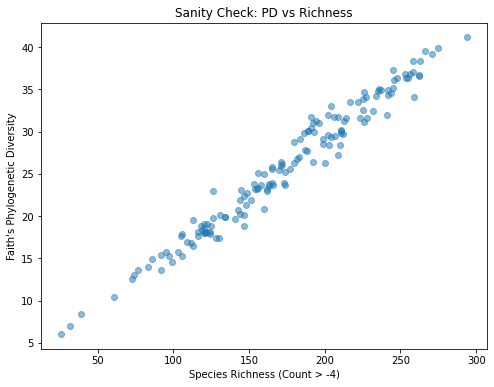

In [23]:
# Sanity check
import matplotlib.pyplot as plt
import scipy.stats as stats

# 1. Calculate Simple Richness (Count of species > -4 log abundance)
# We drop the metadata columns first to ensure we only count bacteria

# 2. Plot
plt.figure(figsize=(8, 6))
plt.scatter(gut_bacteria_df['Richness'], gut_bacteria_df['Faith_index'], alpha=0.5)
plt.xlabel('Species Richness (Count > -4)')
plt.ylabel("Faith's Phylogenetic Diversity")
plt.title('Sanity Check: PD vs Richness')

# 3. Correlation Score
# corr, p_val = stats.spearmanr(gut_bacteria_df['Richness'], gut_bacteria_df['Faith_index'])
# print(f"Spearman Correlation: {corr:.2f} (Should be > 0.8)")
corr, p_val = stats.pearsonr(gut_bacteria_df['Richness'], gut_bacteria_df['Faith_index'])
print(f"Pearson Correlation: {corr:.2f} (Should be > 0.8)")
corr, p_val = stats.pearsonr(gut_bacteria_df['Shannon_diversity'], gut_bacteria_df['Faith_index'])
print(f"Pearson Correlation: {corr:.2f} (Should be > 0.8)")
corr, p_val = stats.pearsonr(gut_bacteria_df['Richness'], gut_bacteria_df['Shannon_diversity'])
print(f"Pearson Correlation: {corr:.2f} (Should be > 0.8)")
plt.show()

In [24]:
diversity_targets = ['Richness', 'Shannon_diversity', 'Faith_index']

## Load Diet Data

In [25]:
with open('/net/mraid20/export/genie/LabData/Analyses/tomerse/david_colab/my_lists_diet.pkl', 'rb') as file:
            loaded_lists = pickle.load(file)
base_features, all_diet_features = loaded_lists

In [26]:
with open('/net/mraid20/export/genie/LabData/Analyses/tomerse/diet_mb/data/food_shortnames.pkl', 'rb') as file:
    food_shortnames = pickle.load(file)
food_shortnames

Index(['Acorn squash', 'Alfalfa sprouts', 'Almond Beverage', 'Almond flour',
       'Almond spread', 'Almonds', 'Amba', 'Apple', 'Apple Cake',
       'Apple Vinegar',
       ...
       'Yellow pepper', 'Yogurt', 'Zaatar', 'Zucchini', 'Zucchini Patties',
       'black pepper', 'dried tomato spread', 'emmer wheat bread', 'ginger',
       'kale'],
      dtype='object', name='shortname_eng', length=570)

In [27]:
# dll = DietLoggingLoader()
# dlld = dll.get_data(study_ids=15, stage='baseline')
# # log = get_diet_logging_around_stage(dlld.df, delta_before=2, delta_after=14)
# log = dlld.df.reset_index()
# log = log.set_index(['RegistrationCode','Date','food_id'])
# print(log.head(10))
# log.shape

In [28]:
# log_date = dll.add_new_nutrients(log)
# log_date

In [29]:
diet_aus = pd.read_csv('/net/mraid20/ifs/wisdom/segal_lab/genie/LabData/Analyses/nastya/diet_predictions/nutr_full_clean_aus.csv', index_col=0)
diet_aus

,Sugar alcohols,SFA 13:0,"Tocotrienol, delta","Tocotrienol, gamma","Tocotrienol, alpha","Fatty acids, total trans-monoenoic","Fatty acids, total trans-polyenoic","Tocopherol, delta","Tocopherol, gamma",PUFA 18:3i,...,MUFA 18:1-11 t (18:1t n-7),"Fluoride, F",Vitamin D3 (cholecalciferol),"TFA 18:2 t,t","Calcium, Ca",Galactose,Theobromine,Iodine,Biotin,Energy
RegistrationCode,,,,,,,,,,,,,,,,,,,,,
3002243,8.363929,0.013355,0.039111,0.381106,1.377526,3.384739,0.548392,5.685655,22.196631,0.070205,...,5.486042,1404.146294,35.161784,4.051402,1044.084451,0.194450,64.233929,5.095714,2.738286,2722.412408
3002905,0.409091,0.002396,0.032473,0.306095,0.589051,2.393944,0.442477,5.479781,20.810984,0.027771,...,5.120025,1132.498702,24.698819,2.075081,1967.868918,0.613236,126.701273,13.974391,9.433636,2446.747244
3014896,0.000000,0.049767,0.062829,0.977160,0.547410,2.293406,0.640618,3.570429,16.690681,0.021976,...,5.213123,536.987756,30.500565,1.590451,774.692329,0.066618,23.011714,4.562714,10.840800,2576.054069
3026711,19.982143,0.000268,0.077810,0.236986,0.377155,1.303912,0.315579,5.148032,15.735059,0.028428,...,3.891844,463.258667,13.430793,1.168945,510.709144,1.162232,60.523095,0.857143,2.862929,1943.021926
3031986,0.000000,0.026846,0.082046,0.794360,0.833545,1.258857,0.298697,3.648543,13.145782,0.080468,...,6.300906,2736.024810,12.902716,0.995391,798.455810,0.576743,9.756333,47.864217,0.455769,1619.096114
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3930708,0.000000,0.082878,1.690744,6.396467,3.583500,1.509483,0.427188,3.488478,18.607744,0.006176,...,2.128947,684.384439,12.756778,1.189192,480.563518,0.128322,59.518889,0.606222,0.000000,1877.124296
3944264,7.375385,0.006818,0.088382,0.579965,0.737116,1.739762,0.388671,3.271094,12.662036,0.019885,...,4.697333,496.616045,17.103716,1.561172,782.223461,0.401192,147.052462,1.073037,8.976688,2004.746895
3962829,6.041177,0.020203,0.002552,2.075162,2.427388,1.991559,0.448299,1.018039,13.960442,0.052568,...,3.471668,269.164314,19.312840,0.642868,427.182928,0.383271,28.528431,0.280059,0.742332,1278.707050


In [30]:
nutr_list_aus = list(diet_aus.columns)

In [31]:
with open('/net/mraid20/export/genie/LabData/Analyses/tomerse/diet_mb/data/nutr_list_aus.pkl', 'wb') as file:
    pickle.dump(nutr_list_aus, file)

In [32]:
nutr_list_no_energy = [nutrient for nutrient in nutr_list_aus if nutrient != "Energy"]
diet_aus[nutr_list_no_energy] = diet_aus[nutr_list_no_energy].div(diet_aus['Energy'], axis=0)

In [33]:
diet_aus

,Sugar alcohols,SFA 13:0,"Tocotrienol, delta","Tocotrienol, gamma","Tocotrienol, alpha","Fatty acids, total trans-monoenoic","Fatty acids, total trans-polyenoic","Tocopherol, delta","Tocopherol, gamma",PUFA 18:3i,...,MUFA 18:1-11 t (18:1t n-7),"Fluoride, F",Vitamin D3 (cholecalciferol),"TFA 18:2 t,t","Calcium, Ca",Galactose,Theobromine,Iodine,Biotin,Energy
RegistrationCode,,,,,,,,,,,,,,,,,,,,,
3002243,0.003072,4.905471e-06,0.000014,0.000140,0.000506,0.001243,0.000201,0.002088,0.008153,0.000026,...,0.002015,0.515773,0.012916,0.001488,0.383514,0.000071,0.023594,0.001872,0.001006,2722.412408
3002905,0.000167,9.793336e-07,0.000013,0.000125,0.000241,0.000978,0.000181,0.002240,0.008506,0.000011,...,0.002093,0.462859,0.010095,0.000848,0.804280,0.000251,0.051784,0.005711,0.003856,2446.747244
3014896,0.000000,1.931892e-05,0.000024,0.000379,0.000212,0.000890,0.000249,0.001386,0.006479,0.000009,...,0.002024,0.208454,0.011840,0.000617,0.300728,0.000026,0.008933,0.001771,0.004208,2576.054069
3026711,0.010284,1.377824e-07,0.000040,0.000122,0.000194,0.000671,0.000162,0.002649,0.008098,0.000015,...,0.002003,0.238422,0.006912,0.000602,0.262843,0.000598,0.031149,0.000441,0.001473,1943.021926
3031986,0.000000,1.658095e-05,0.000051,0.000491,0.000515,0.000778,0.000184,0.002253,0.008119,0.000050,...,0.003892,1.689847,0.007969,0.000615,0.493149,0.000356,0.006026,0.029562,0.000281,1619.096114
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3930708,0.000000,4.415146e-05,0.000901,0.003408,0.001909,0.000804,0.000228,0.001858,0.009913,0.000003,...,0.001134,0.364592,0.006796,0.000634,0.256010,0.000068,0.031707,0.000323,0.000000,1877.124296
3944264,0.003679,3.400775e-06,0.000044,0.000289,0.000368,0.000868,0.000194,0.001632,0.006316,0.000010,...,0.002343,0.247720,0.008532,0.000779,0.390186,0.000200,0.073352,0.000535,0.004478,2004.746895
3962829,0.004724,1.579965e-05,0.000002,0.001623,0.001898,0.001557,0.000351,0.000796,0.010918,0.000041,...,0.002715,0.210497,0.015103,0.000503,0.334074,0.000300,0.022310,0.000219,0.000581,1278.707050


In [34]:
# Unite similar features by summing them up
# diet_aus['omega_6'] = diet_aus[['PUFA 18:2 n-6 c,c', 'PUFA 20:4 n-6', 'PUFA 18:2 CLAs', 'PUFA 18:2 i', 'PUFA 20:2 n-6 c,c', 'PUFA 2:4 n-6', 'PUFA 22:4', 'PUFA 18:3 n-6 c,c,c']].sum(axis=1)
# diet_aus['omega_3'] = diet_aus[['PUFA 18:3 n-3 c,c,c (ALA)', 'PUFA 18:4', 'PUFA 20:5 n-3 (EPA)', 'PUFA 22:6 n-3 (DHA)', 'PUFA 22:5 n-3 (DPA)', 'PUFA 20:3 n-3']].sum(axis=1)
# diet_aus['vitamin_E'] = diet_aus[['Vitamin E (alpha-tocopherol)', 'Tocopherol, beta', 'Tocopherol, delta', 'Tocopherol, gamma', 'Tocotrienol, alpha', 'Tocotrienol, beta', 'Tocotrienol, delta', 'Tocotrienol, gamma']].sum(axis=1)

# Drop the original columns after uniting
# columns_to_drop = [
#     'SFA 4:0', 'SFA 6:0', 'SFA 8:0', 'SFA 10:0', 'SFA 12:0', 'SFA 14:0', 'SFA 16:0', 'SFA 18:0', 'SFA 13:0', 'SFA 15:0', 'SFA 17:0', 'SFA 20:0', 'SFA 22:0', 'SFA 24:0',
#     'MUFA 14:1', 'MUFA 15:1', 'MUFA 16:1', 'MUFA 17:1', 'MUFA 18:1', 'MUFA 18:1 c', 'MUFA 20:1', 'MUFA 22:1', 'MUFA 24:1 c', 'MUFA 16:1 c', 'MUFA 22:1 c', 'MUFA 18:1-11 t (18:1t n-7)',
#     'PUFA 18:2 n-6 c,c', 'PUFA 20:4 n-6', 'PUFA 18:2 CLAs', 'PUFA 18:2 i', 'PUFA 20:2 n-6 c,c', 'PUFA 2:4 n-6', 'PUFA 22:4', 'PUFA 18:3 n-6 c,c,c',
#     'PUFA 18:3 n-3 c,c,c (ALA)', 'PUFA 18:4', 'PUFA 20:5 n-3 (EPA)', 'PUFA 22:6 n-3 (DHA)', 'PUFA 22:5 n-3 (DPA)', 'PUFA 20:3 n-3',
#     'TFA 16:1 t', 'TFA 18:1 t', 'TFA 18:2 t not further defined', 'TFA 18:2 t,t', 'TFA 22:1 t',
#     'Vitamin A, IU', 'Carotene, beta', 'Retinol', 'Carotene, alpha', 'Cryptoxanthin, beta',
#     'Vitamin D2 (ergocalciferol)', 'Vitamin D3 (cholecalciferol)', 'Vitamin D (D2 + D3), International Units', 
#     'Vitamin K (Dihydrophylloquinone)', 'Vitamin K (Menaquinone-4)', 'Vitamin K (phylloquinone)',
#     'Vitamin E (alpha-tocopherol)', 'Tocopherol, beta', 'Tocopherol, delta', 'Tocopherol, gamma', 'Tocotrienol, alpha', 'Tocotrienol, beta', 'Tocotrienol, delta', 'Tocotrienol, gamma', 'Vitamin E, added',
#     'Folate, DFE', 'Sugars, total including NLEA',
#     'Fatty acids, total trans-monoenoic', 'Fatty acids, total trans-polyenoic', 'Folate, DFE', 'Folate, food', 'Folic acid',
#     'Galactose', 'Lactose', 'Maltose',  'PUFA 18:2', 'PUFA 18:3', 'PUFA 18:3i', 'PUFA 20:3', 'PUFA 20:4', 'PUFA 21:5',
#     'Theobromine', 'Stigmasterol', 'Beta-sitosterol', 'Sucrose', 'matched_food_score',
#     'Isoleucine', 'Leucine', 'Valine', 'Lysine', 'Threonine', 'Methionine', 'Phenylalanine', 'Tryptophan', 'Histidine',
#     'Tyrosine', 'Arginine', 'Cystine', 'Serine', 'Alanine', 'Aspartic acid', 'Glutamic acid', 'Glycine', 'Hydroxyproline', 'Proline'
# ]

# diet_aus.drop(columns=columns_to_drop, inplace=True)

# # Optional: remove additional duplicates like 'Vitamin B-12, added' if needed
# diet_aus.drop(columns=['Vitamin B-12, added'], inplace=True, errors='ignore')

# # Ensure to keep only 'Folate, total'
# diet_aus = diet_aus.loc[:, ~diet_aus.columns.duplicated()]


### END

### BMI

In [35]:
bml = BodyMeasuresLoader()
# bmld = bml.get_data(study_ids=study_ids, cols=['weight', 'height', 'bmr'])
bmld = bml.get_data(study_ids=study_ids)
bmldf = bmld.df
bmldf.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 393 entries, ('3002243', Timestamp('2023-06-25 00:00:00')) to ('3976912', Timestamp('2021-05-15 00:00:00'))
Data columns (total 35 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   number_of_days_from_last_period               0 non-null      float64
 1   height                                        274 non-null    float64
 2   fingers_grip_left                             0 non-null      float64
 3   bmi                                           274 non-null    float64
 4   hand_grip_left                                0 non-null      float64
 5   trunk_fat                                     0 non-null      float64
 6   lying_blood_pressure_systolic                 0 non-null      float64
 7   on_hormone_therapy                            0 non-null      object 
 8   standing_one_min_blood_pressure_systolic      0 non-nu

In [36]:
# if stage == 'baseline':
    # Keep only baseline
bmldf = bmldf[~bmldf.index.get_level_values(0).duplicated()]
bmldf = bmldf.reset_index(level=[1], drop=True)
# elif stage == '02_00_visit':
#     # Keep only the second entry (2nd visit)
#     bmldf = bmldf.groupby(level=0).nth(1) 
# elif stage == '04_00_visit':
#     # Keep only the second entry (3rd visit)
#     bmldf = bmldf.groupby(level=0).nth(1) 
bmldf

,number_of_days_from_last_period,height,fingers_grip_left,bmi,hand_grip_left,trunk_fat,lying_blood_pressure_systolic,on_hormone_therapy,standing_one_min_blood_pressure_systolic,hips,...,standing_three_min_blood_pressure_diastolic,body_fat,bmr,lying_blood_pressure_pulse_rate,sitting_blood_pressure_systolic,standing_one_min_blood_pressure_diastolic,whr,dominant_hand,weight,is_getting_period
RegistrationCode,,,,,,,,,,,,,,,,,,,,,
3002243,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,92.0,...,NaN,25.200001,1559.0,NaN,135.0,NaN,1.010870,NaN,76.199997,NaN
3002905,NaN,175.000000,NaN,30.824490,NaN,NaN,NaN,NaN,NaN,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,0.880342,NaN,94.400002,NaN
3014896,NaN,188.600006,NaN,34.495396,NaN,NaN,NaN,NaN,NaN,116.0,...,NaN,40.799999,2308.0,NaN,134.0,NaN,1.086207,NaN,122.699997,NaN
3026711,NaN,169.000000,NaN,48.317635,NaN,NaN,NaN,NaN,NaN,149.0,...,NaN,46.200001,2017.0,NaN,164.0,NaN,0.818792,NaN,138.000000,NaN
3031986,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,97.0,...,NaN,34.500000,1267.0,NaN,143.0,NaN,0.804124,NaN,60.200001,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3930708,NaN,159.000000,NaN,27.649223,NaN,NaN,NaN,NaN,NaN,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,0.882353,NaN,69.900002,NaN
3944264,NaN,165.000000,NaN,30.927456,NaN,NaN,NaN,NaN,NaN,113.0,...,NaN,42.799999,1465.0,NaN,148.0,NaN,0.991150,NaN,84.199997,NaN
3962829,NaN,154.000000,NaN,37.400909,NaN,NaN,NaN,NaN,NaN,114.0,...,NaN,45.200001,1506.0,NaN,166.0,NaN,0.859649,NaN,88.699997,NaN


## Combine Dataframes

In [37]:
# baseline_nutrients = baseline_nutrients.set_index('RegistrationCode')
# baseline_nutrients.columns = [rename_dict.get(item, item) for item in baseline_nutrients.columns]
# baseline_nutrients

In [38]:
# diet_mb = baseline_foods.join(baseline_nutrients, how='inner')
# # diet_mb = diet_mb.dropna()
# diet_mb

In [39]:
subjects_df = subjects_df.reset_index(level=[1], drop=True)
subjects_df

,StudyTypeID,city,country,gender,month_of_birth,us_state,yob,StudyTypeID2,StudyTypeID3,StudyTypeID4,StudyTypeID5,StudyTypeID6,StudyTypeID7,StudyTypeID8,StudyTypeID9,age,tz
RegistrationCode,,,,,,,,,,,,,,,,,
3002243,15.0,None,AU,NaN,None,None,NaN,None,None,None,None,None,None,None,None,NaN,Australia/Sydney
3002905,15.0,None,AU,0.0,None,None,1955.0,None,None,None,None,None,None,None,None,68.0,Australia/Sydney
3006146,15.0,None,AU,NaN,None,None,NaN,None,None,None,None,None,None,None,None,NaN,Australia/Sydney
3014896,15.0,None,AU,1.0,None,None,1964.0,None,None,None,None,None,None,None,None,56.0,Australia/Sydney
3015169,15.0,None,AU,NaN,None,None,NaN,None,None,None,None,None,None,None,None,NaN,Australia/Sydney
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3974179,15.0,None,AU,1.0,None,None,1963.0,None,None,None,None,None,None,None,None,57.0,Australia/Sydney
3976912,15.0,None,AU,0.0,None,None,1978.0,None,None,None,None,None,None,None,None,42.0,Australia/Sydney
3987074,15.0,None,AU,NaN,None,None,NaN,None,None,None,None,None,None,None,None,NaN,Australia/Sydney


In [40]:
base_features = ["age", "gender"]
subjects_df.index = subjects_df.index.astype('int')
diet_aus = diet_aus.join(subjects_df[base_features])
diet_aus = diet_aus.rename(columns={'gender': 'sex'})
# diet_mb = diet_mb.reset_index(level=[1], drop=True)
# diet_mb = diet_mb.dropna()
diet_aus

,Sugar alcohols,SFA 13:0,"Tocotrienol, delta","Tocotrienol, gamma","Tocotrienol, alpha","Fatty acids, total trans-monoenoic","Fatty acids, total trans-polyenoic","Tocopherol, delta","Tocopherol, gamma",PUFA 18:3i,...,Vitamin D3 (cholecalciferol),"TFA 18:2 t,t","Calcium, Ca",Galactose,Theobromine,Iodine,Biotin,Energy,age,sex
RegistrationCode,,,,,,,,,,,,,,,,,,,,,
3002243,0.003072,4.905471e-06,0.000014,0.000140,0.000506,0.001243,0.000201,0.002088,0.008153,0.000026,...,0.012916,0.001488,0.383514,0.000071,0.023594,0.001872,0.001006,2722.412408,NaN,NaN
3002905,0.000167,9.793336e-07,0.000013,0.000125,0.000241,0.000978,0.000181,0.002240,0.008506,0.000011,...,0.010095,0.000848,0.804280,0.000251,0.051784,0.005711,0.003856,2446.747244,68.0,0.0
3014896,0.000000,1.931892e-05,0.000024,0.000379,0.000212,0.000890,0.000249,0.001386,0.006479,0.000009,...,0.011840,0.000617,0.300728,0.000026,0.008933,0.001771,0.004208,2576.054069,56.0,1.0
3026711,0.010284,1.377824e-07,0.000040,0.000122,0.000194,0.000671,0.000162,0.002649,0.008098,0.000015,...,0.006912,0.000602,0.262843,0.000598,0.031149,0.000441,0.001473,1943.021926,57.0,0.0
3031986,0.000000,1.658095e-05,0.000051,0.000491,0.000515,0.000778,0.000184,0.002253,0.008119,0.000050,...,0.007969,0.000615,0.493149,0.000356,0.006026,0.029562,0.000281,1619.096114,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3930708,0.000000,4.415146e-05,0.000901,0.003408,0.001909,0.000804,0.000228,0.001858,0.009913,0.000003,...,0.006796,0.000634,0.256010,0.000068,0.031707,0.000323,0.000000,1877.124296,34.0,0.0
3944264,0.003679,3.400775e-06,0.000044,0.000289,0.000368,0.000868,0.000194,0.001632,0.006316,0.000010,...,0.008532,0.000779,0.390186,0.000200,0.073352,0.000535,0.004478,2004.746895,63.0,0.0
3962829,0.004724,1.579965e-05,0.000002,0.001623,0.001898,0.001557,0.000351,0.000796,0.010918,0.000041,...,0.015103,0.000503,0.334074,0.000300,0.022310,0.000219,0.000581,1278.707050,59.0,0.0


In [41]:
bmldf.index = bmldf.index.astype('int')

diet_aus = diet_aus.join(bmldf['bmi'], how='inner')
diet_aus.shape

(132, 113)

In [42]:
baseline_mb.index = baseline_mb.index.astype('int')
diet_mb_baseline = diet_aus.join(baseline_mb)
diet_mb_baseline

,Sugar alcohols,SFA 13:0,"Tocotrienol, delta","Tocotrienol, gamma","Tocotrienol, alpha","Fatty acids, total trans-monoenoic","Fatty acids, total trans-polyenoic","Tocopherol, delta","Tocopherol, gamma",PUFA 18:3i,...,fBin__94|gBin__448|sBin__654,fBin__94|gBin__449|sBin__656,fBin__95|gBin__450|sBin__659,fBin__96|gBin__457|sBin__669,fBin__97|gBin__462|sBin__676,fBin__97|gBin__462|sBin__678,fBin__99|gBin__469|sBin__687,Richness,Shannon_diversity,Faith_index
RegistrationCode,,,,,,,,,,,,,,,,,,,,,
3002243,0.003072,4.905471e-06,0.000014,0.000140,0.000506,0.001243,0.000201,0.002088,0.008153,0.000026,...,-4.000000,-4.000000,-4.0,-4.0,-4.0,-3.876399,-4.000000,112.0,1.72,16.773147
3002905,0.000167,9.793336e-07,0.000013,0.000125,0.000241,0.000978,0.000181,0.002240,0.008506,0.000011,...,-4.000000,-3.348414,-4.0,-4.0,-4.0,-3.748365,-4.000000,226.0,4.06,34.726523
3014896,0.000000,1.931892e-05,0.000024,0.000379,0.000212,0.000890,0.000249,0.001386,0.006479,0.000009,...,-3.396085,-4.000000,-4.0,-4.0,-4.0,-3.785510,-4.000000,193.0,3.80,30.010677
3026711,0.010284,1.377824e-07,0.000040,0.000122,0.000194,0.000671,0.000162,0.002649,0.008098,0.000015,...,-4.000000,-4.000000,-4.0,-4.0,-4.0,-4.000000,-4.000000,131.0,2.51,20.196066
3031986,0.000000,1.658095e-05,0.000051,0.000491,0.000515,0.000778,0.000184,0.002253,0.008119,0.000050,...,-4.000000,-4.000000,-4.0,-4.0,-4.0,-2.865261,-4.000000,147.0,3.67,22.369123
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3930708,0.000000,4.415146e-05,0.000901,0.003408,0.001909,0.000804,0.000228,0.001858,0.009913,0.000003,...,-4.000000,-4.000000,-4.0,-4.0,-4.0,-4.000000,-1.163339,120.0,2.94,18.057970
3944264,0.003679,3.400775e-06,0.000044,0.000289,0.000368,0.000868,0.000194,0.001632,0.006316,0.000010,...,-4.000000,-4.000000,-4.0,-4.0,-4.0,-4.000000,-4.000000,39.0,2.41,8.391606
3962829,0.004724,1.579965e-05,0.000002,0.001623,0.001898,0.001557,0.000351,0.000796,0.010918,0.000041,...,-4.000000,-4.000000,-4.0,-4.0,-4.0,-4.000000,-4.000000,121.0,3.27,18.148488


In [43]:
# Baseline data shape
print(diet_mb_baseline.shape)

(132, 840)


In [44]:
# from sklearn.preprocessing import StandardScaler

# with open(home_path + f'data/{SPECIES}/age_scaler.pkl', 'rb') as f:
#     age_scaler = pickle.load(f)

# with open(home_path + f'data/{SPECIES}/mb_scaler.pkl', 'rb') as f:
#     mb_scaler = pickle.load(f)

# with open(home_path + f'data/{SPECIES}/div_scaler.pkl', 'rb') as f:
#     div_scaler = pickle.load(f)

# diet_scaler = StandardScaler()
# diet_mb_10k_scaled = diet_scaler.fit_transform(diet_mb_10k[aus_10k_shared_features])

# # # Apply the scaler to the dataframe
# diet_mb_baseline.loc[:, aus_10k_shared_features] = diet_scaler.transform(diet_mb_baseline[aus_10k_shared_features])
# diet_mb_baseline.loc[:, ["age"]] = age_scaler.transform(diet_mb_baseline[["age"]])
# diet_mb_baseline.loc[:, targets_10k] = mb_scaler.transform(diet_mb_baseline[targets_10k])
# diet_mb_baseline.loc[:, ["Richness", "Shannon_diversity"]] = div_scaler.transform(diet_mb_baseline[["Richness", "Shannon_diversity"]])
# # diet_mb_baseline[aus_10k_shared_features] = pd.DataFrame(scaler.transform(diet_mb_baseline[aus_10k_shared_features]), columns=diet_mb_baseline[aus_10k_shared_features].columns, index=diet_mb_baseline[aus_10k_shared_features].index)
# diet_mb_baseline.describe()

In [45]:
# Scaling code for baseline (commented out)
# diet_mb_baseline.loc[:, aus_10k_shared_features] = diet_scaler.transform(diet_mb_baseline[aus_10k_shared_features])
# diet_mb_baseline.loc[:, ["age"]] = age_scaler.transform(diet_mb_baseline[["age"]])
# diet_mb_baseline.loc[:, targets_10k] = mb_scaler.transform(diet_mb_baseline[targets_10k])
# diet_mb_baseline.loc[:, ["Richness", "Shannon_diversity"]] = div_scaler.transform(diet_mb_baseline[["Richness", "Shannon_diversity"]])
# diet_mb_baseline.describe()

In [46]:
# Count rows that have at least one NaN
nan_rows = diet_mb_baseline[diet_mb_baseline.isna().any(axis=1)]
num_nan_rows = len(nan_rows)

# Find which columns contain NaN values
nan_features = diet_mb_baseline.columns[diet_mb_baseline.isna().any()].tolist()

print(f"Number of rows with at least one NaN: {num_nan_rows}")
print("Features that contain NaN values:")
print(nan_features)


Number of rows with at least one NaN: 20
Features that contain NaN values:
['age', 'sex', 'bmi', 'fBin__100|gBin__473|sBin__693', 'fBin__100|gBin__473|sBin__694', 'fBin__100|gBin__474|sBin__695', 'fBin__100|gBin__477|sBin__698', 'fBin__100|gBin__481|sBin__704', 'fBin__100|gBin__481|sBin__705', 'fBin__100|gBin__481|sBin__706', 'fBin__100|gBin__483|sBin__709', 'fBin__102|gBin__490|sBin__720', 'fBin__102|gBin__490|sBin__721', 'fBin__102|gBin__490|sBin__722', 'fBin__103|gBin__491|sBin__727', 'fBin__104|gBin__493|sBin__730', 'fBin__104|gBin__494|sBin__731', 'fBin__104|gBin__495|sBin__732', 'fBin__104|gBin__496|sBin__733', 'fBin__104|gBin__496|sBin__734', 'fBin__104|gBin__498|sBin__736', 'fBin__104|gBin__500|sBin__738', 'fBin__108|gBin__515|sBin__766', 'fBin__108|gBin__515|sBin__767', 'fBin__108|gBin__517|sBin__769', 'fBin__108|gBin__521|sBin__773', 'fBin__108|gBin__523|sBin__776', 'fBin__108|gBin__525|sBin__778', 'fBin__108|gBin__526|sBin__779', 'fBin__108|gBin__531|sBin__787', 'fBin__121|g

In [47]:
print("\nNaN count per column:")
print(diet_mb_baseline.isna().sum()[diet_mb_baseline.isna().sum() > 0])
diet_mb_baseline = diet_mb_baseline.dropna(how='any')



NaN count per column:
age                              12
sex                              12
bmi                              16
fBin__100|gBin__473|sBin__693     2
fBin__100|gBin__473|sBin__694     2
                                 ..
fBin__97|gBin__462|sBin__678      2
fBin__99|gBin__469|sBin__687      2
Richness                          2
Shannon_diversity                 2
Faith_index                       2
Length: 730, dtype: int64


In [48]:
print(diet_mb_baseline.shape)

(112, 840)


In [49]:
diet_mb_baseline.to_pickle(home_path + f'data/segal_species/diet_mb_{study_name.lower()}_baseline.pkl')
with open(home_path + f'data/segal_species/my_lists_{study_name.lower()}.pkl', 'wb') as file:
    pickle.dump([nutr_list_aus, targets_10k], file)

In [52]:
diet_mb_baseline.columns

Index(['Sugar alcohols', 'SFA 13:0', 'Tocotrienol, delta',
       'Tocotrienol, gamma', 'Tocotrienol, alpha',
       'Fatty acids, total trans-monoenoic',
       'Fatty acids, total trans-polyenoic', 'Tocopherol, delta',
       'Tocopherol, gamma', 'PUFA 18:3i',
       ...
       'fBin__94|gBin__448|sBin__654', 'fBin__94|gBin__449|sBin__656',
       'fBin__95|gBin__450|sBin__659', 'fBin__96|gBin__457|sBin__669',
       'fBin__97|gBin__462|sBin__676', 'fBin__97|gBin__462|sBin__678',
       'fBin__99|gBin__469|sBin__687', 'Richness', 'Shannon_diversity',
       'Faith_index'],
      dtype='object', length=840)

In [50]:
print(len(nutr_list_aus))
print(len(targets_10k))

110
724


### Phenotype data

In [51]:
all_meas=pd.read_csv('/net/mraid20/export/genie/LabData/Data/StudySpecificData/AUS_Predict/intervention/all_results.csv')
all_meas=all_meas[[col for col in all_meas.columns if 'start' in col]]
all_meas=all_meas.rename(columns={col:col.replace('_start', '') for col in all_meas.columns})